<a href="https://colab.research.google.com/github/lalitha-sahitya/Rainfall-prediction/blob/main/rainfall_prediction_using_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np

In [ ]:
od.download('https://www.kaggle.com/competitions/playground-series-s5e3')

Skipping, found downloaded files in "./playground-series-s5e3" (use force=True to force download)


In [ ]:
os.listdir('playground-series-s5e3')

['sample_submission.csv', 'test.csv', 'train.csv']

In [ ]:
data=pd.read_csv('playground-series-s5e3/train.csv')
test_data=pd.read_csv('playground-series-s5e3/test.csv')

In [ ]:
data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [ ]:
test_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [ ]:
data=data.drop(['id','day'],axis=1)
test_data=test_data.drop(['id','day'],axis=1)

In [ ]:
data.shape

(2190, 11)

In [ ]:
test_data.shape

(730, 10)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pressure       2190 non-null   float64
 1   maxtemp        2190 non-null   float64
 2   temparature    2190 non-null   float64
 3   mintemp        2190 non-null   float64
 4   dewpoint       2190 non-null   float64
 5   humidity       2190 non-null   float64
 6   cloud          2190 non-null   float64
 7   sunshine       2190 non-null   float64
 8   winddirection  2190 non-null   float64
 9   windspeed      2190 non-null   float64
 10  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 188.3 KB


In [ ]:
data.isna().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
sunshine,0
winddirection,0
windspeed,0


In [ ]:
data.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


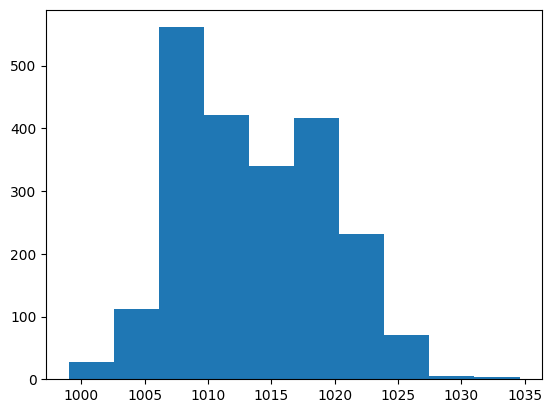

pressure


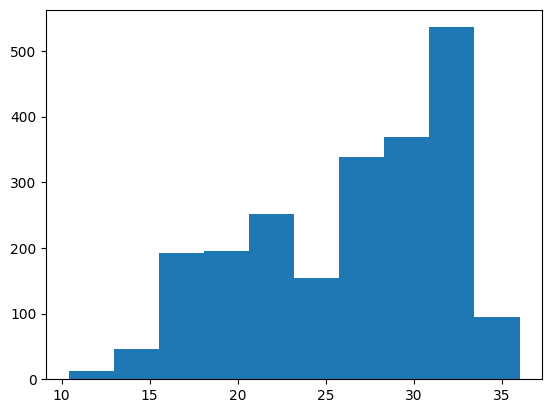

maxtemp


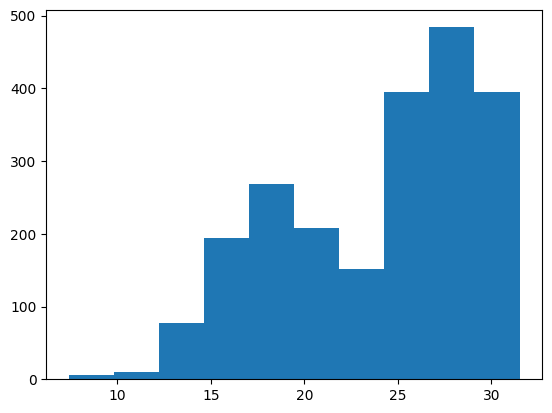

temparature


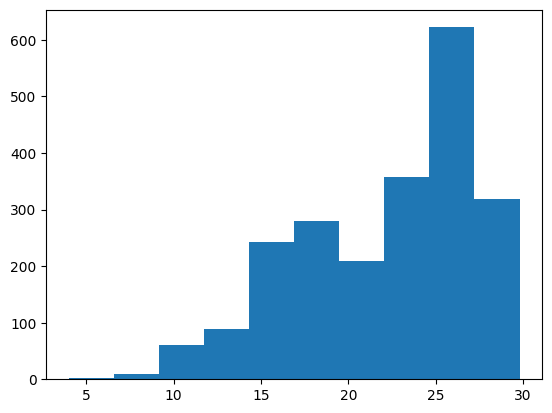

mintemp


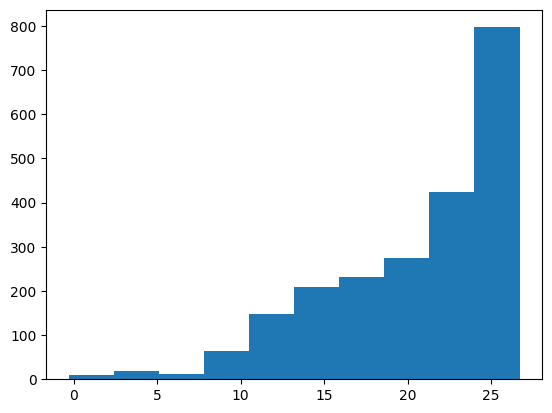

dewpoint


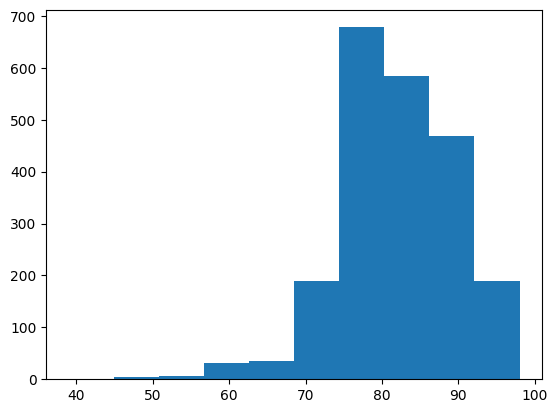

humidity


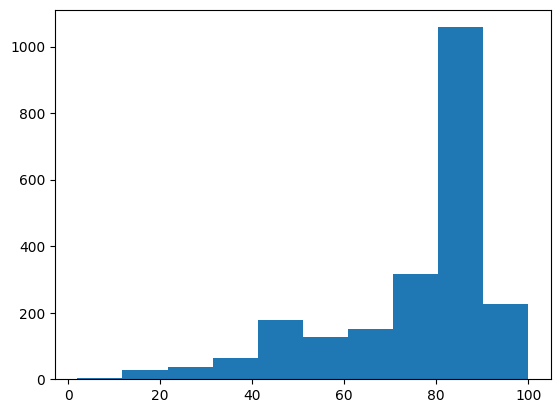

cloud


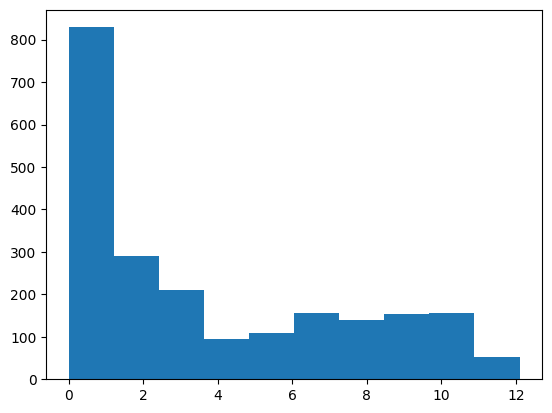

sunshine


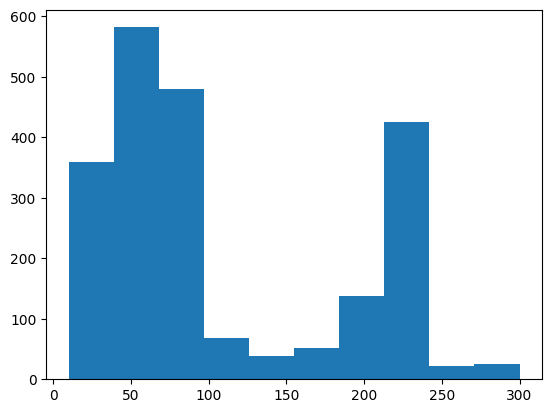

winddirection


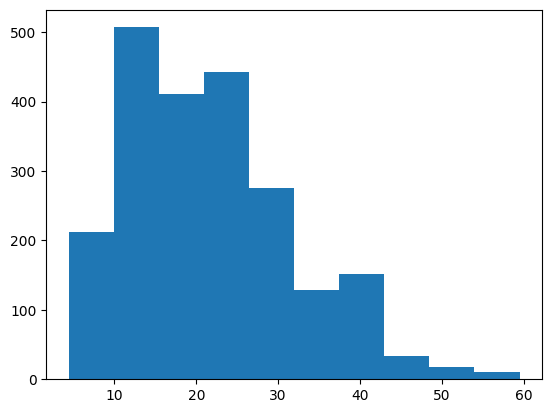

windspeed


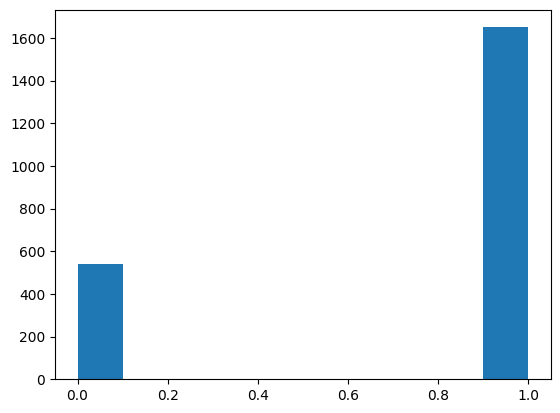

rainfall


In [ ]:
import matplotlib.pyplot as plt
for i in data.columns:
  plt.hist(data[i])
  plt.show()
  print(i)

In [ ]:
x=data.drop('rainfall',axis=1)
y=data['rainfall']

In [ ]:
x.shape

(2190, 10)

In [ ]:
y.shape

(2190,)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(1752, 10)

In [ ]:
x_test.shape

(438, 10)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(10,)),
    keras.layers.Dense(10,activation='relu'),
    keras.layers.Dense(2,activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,validation_split=0.1,epochs=10)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.2415 - loss: 1.3758 - val_accuracy: 0.3523 - val_loss: 0.9057
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4031 - loss: 0.8416 - val_accuracy: 0.6648 - val_loss: 0.6495
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6993 - loss: 0.6103 - val_accuracy: 0.7727 - val_loss: 0.5445
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8070 - loss: 0.5126 - val_accuracy: 0.8011 - val_loss: 0.4877
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8411 - loss: 0.4341 - val_accuracy: 0.8011 - val_loss: 0.4524
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8362 - loss: 0.4141 - val_accuracy: 0.8466 - val_loss: 0.4279
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8658 - loss: 0.3821 - val_accuracy: 0.8352 - val_loss: 0.4117
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8588 - loss: 0.3636 - val_accuracy: 0.8409 - val_l

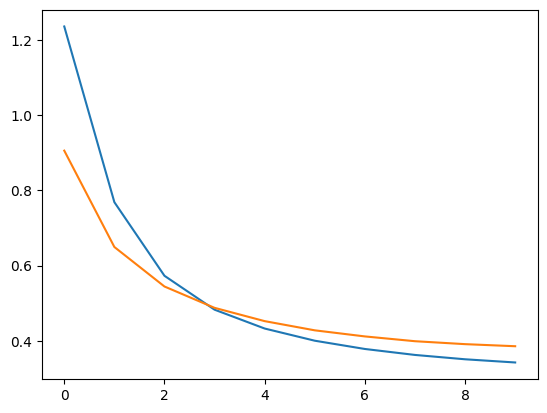

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

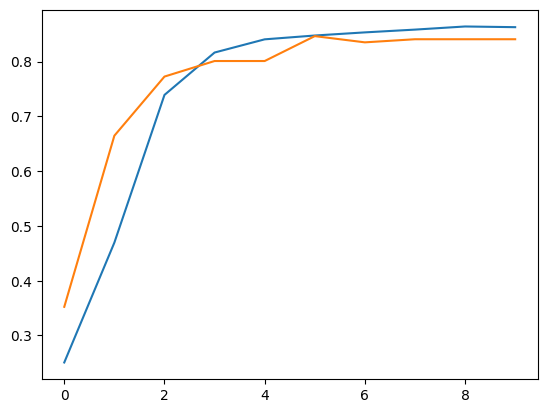

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [ ]:
model.evaluate(x_test,y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8619 - loss: 0.3865 


[0.38777923583984375, 0.8515982031822205]

In [ ]:
test_data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pressure       730 non-null    float64
 1   maxtemp        730 non-null    float64
 2   temparature    730 non-null    float64
 3   mintemp        730 non-null    float64
 4   dewpoint       730 non-null    float64
 5   humidity       730 non-null    float64
 6   cloud          730 non-null    float64
 7   sunshine       730 non-null    float64
 8   winddirection  729 non-null    float64
 9   windspeed      730 non-null    float64
dtypes: float64(10)
memory usage: 57.2 KB


In [ ]:
test_data.shape

(730, 10)

In [ ]:
test_data=sc.transform(test_data)

In [ ]:
preds=model.predict(test_data)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
preds[:10]

array([[0.5540881 , 0.97489846],
       [0.58512306, 0.99064016],
       [0.7712799 , 0.96431816],
       [0.8986288 , 0.7298437 ],
       [0.8946901 , 0.70259833],
       [0.726379  , 0.96870357],
       [0.692836  , 0.9724364 ],
       [0.6005743 , 0.98660153],
       [0.67254823, 0.96663016],
       [0.8524904 , 0.95557296]], dtype=float32)

In [ ]:
pred=np.argmax(preds,axis=1)

In [ ]:
pred[:10]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [ ]:
sub=pd.read_csv('playground-series-s5e3/sample_submission.csv')

In [ ]:
sub.head()

,id,rainfall
0,2190,0
1,2191,0
2,2192,0
3,2193,0
4,2194,0


In [ ]:
sub['rainfall']=pred

In [ ]:
sub

,id,rainfall
0,2190,1
1,2191,1
2,2192,1
3,2193,0
4,2194,0
...,...,...
725,2915,1
726,2916,1
727,2917,1
728,2918,1


In [ ]:
sub.to_csv('sub.csv',index=None)